In [ ]:
#| default_exp dtw_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Dynamic Time Warping

In [ ]:
#| eval: false
from fhemb.utils.cutils import depict_DTW, calc_dtw_accuracy, prepare_data, depict_accuracy_by_feature, depict_combined_accuracy, \
plot_dm_heatmap, plot_dm_projection, svd_dmatrix

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
 [DEBUG] cutils.<module>: ROOT: /Users/radned/Projects/ttsembedding/


In [ ]:
#| eval: false
from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

## Visualize DTW Alignment Using a Distance Metrics 

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

### DTW alignment between two time series

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature pc0 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for pc0
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features pc0
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2

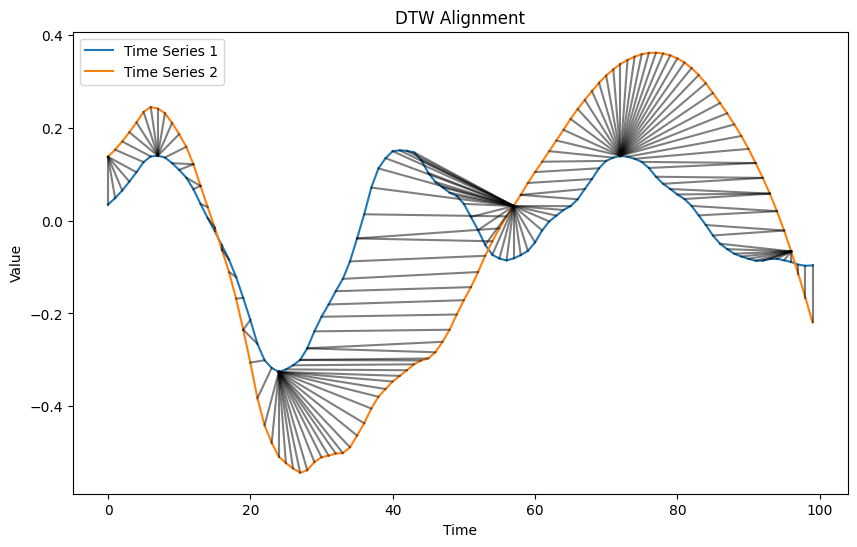

In [ ]:
#| eval: false

depict_DTW(
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj50'][:100], 
    emb_prj_decomp_rec1.get_df_ts_subjs('pc0')['pcomponents_ts']['subj51'][:100],
    dist=euclidean
)

### Depict distance matrix between multiple time series as a heatmap

In [ ]:
#| eval: false

from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] mixins.wrapper: wrapper of process_

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [01:12<00:00, 28.73it/s]


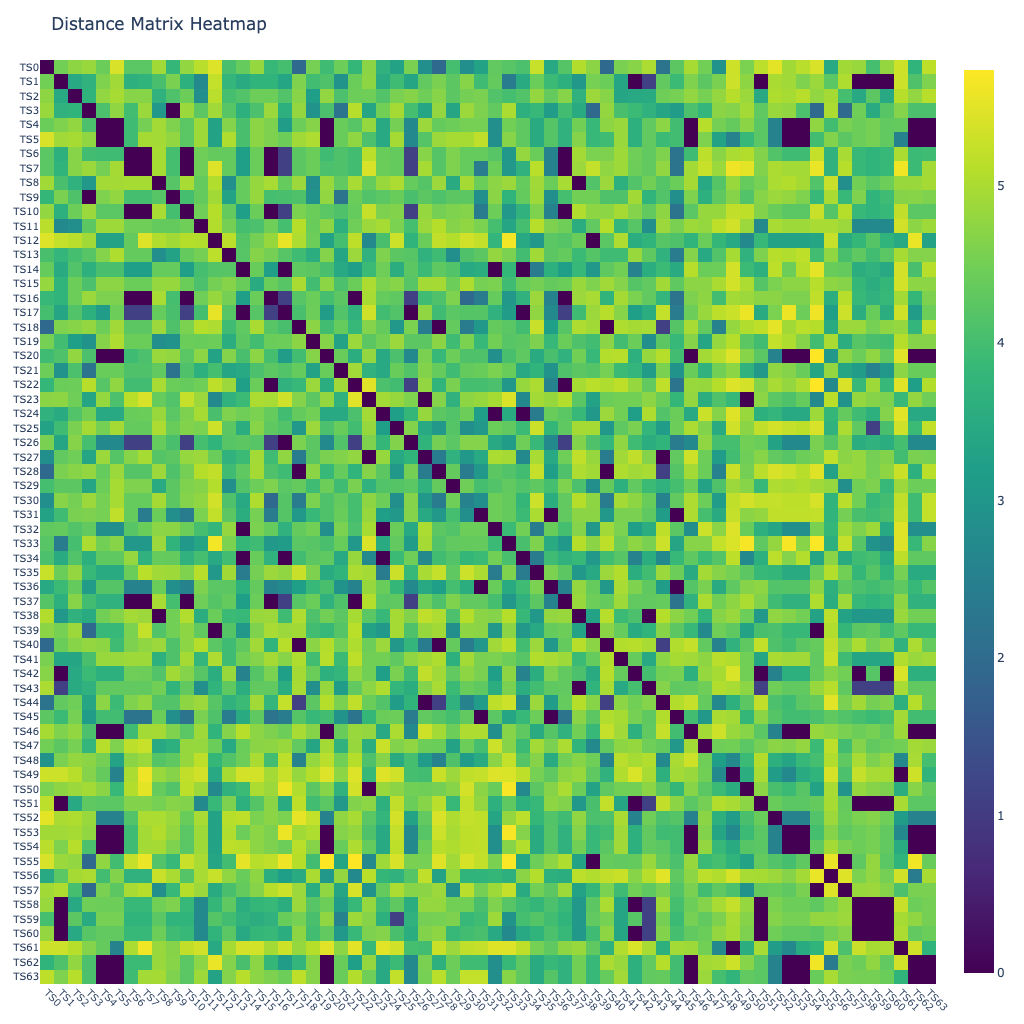

In [ ]:
#| eval: false

plot_dm_heatmap(
    Xdm,                       # data matrix (64 x 64) 
    alignment_type='fastdtw',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # distance metric function used inside fastdtw
    radius=2,                  # refinement window size in fastdtw
    normalize='log',           # normalization method for distance matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
)  

::: {.callout-important title="Landmark embedding"}
The DTW distance matrix is computed over embedded time series (primary embedding). A row of this matrix defines a landmark embedding: the vector of DTW dissimilarities from a given embedded time series to all other embedded time series.
Thus, the landmark embedding is a second‑order embedding determined jointly by the primary embedding and by the DTW configuration (alignment_type, dist, radius, normalize).
:::

### Distance matrix projection using a dimensionality reduction method

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [00:39<00:00, 52.15it/s]
 [WARNING] cutils.plot_dm_projection: PCA assumes a feature matrix, not a distance matrix. Consider using MDS or TSNE for distance-based projections.


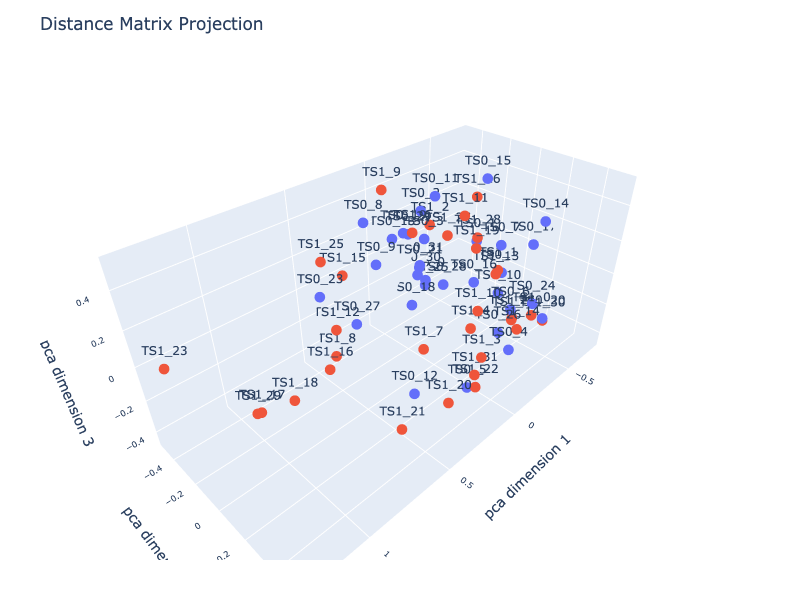

In [ ]:
#| eval: false

plot_dm_projection(
    Xdm[:32], Xdm[32:],         # data matrices for two groups (32 x 64)
    alignment_type='fastdtw',   # alignment method for distance matrix computation           
    dist=cosine,                # distance metric function used inside fastdtw     
    projection='pca',           # projection method for dimensionality reduction ('pca', 'tsne', 'mds') 
    transformation='minmax',    # to transform distances into similarities for PCA
    normalize='log',            # normalization method for distance matrix
    n_jobs=8,                   # number of jobs for parallelization
    dimensions=3,               # number of dimensions of the projection
) 

### Intrinsic dimensionality of a distance matrix via singular value decomposition (SVD)

In [ ]:
#| eval: false

U, S, Vt = svd_dmatrix(       # returns U, S, Vt matrices from SVD of the distance matrix
    Xdm,                      # data matrix (64 x 64)
    alignment_type='fastdtw', # alignment method for distance matrix computation
    dist=cosine,              # distance metric function used inside fastdtw
    radius=2,                 # refinement window size in fastdtw
    transformation='minmax',  # to transform distances into similarities for SVD
    normalize='log',          # normalization method for distance matrix
    n_jobs=8                  # number of jobs for parallelization
)

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [01:02<00:00, 33.04it/s]


#### Visualize the singular-value spectrum
>The vector S contains the singular values returned by the SVD. By convention, these values are sorted in descending order, so the first one corresponds to the dominant singular value and subsequent entries decrease monotonically.

In [ ]:
#| eval: false
import matplotlib.pyplot as plt


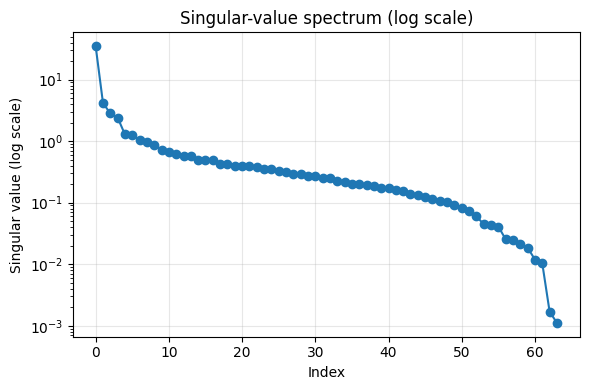

In [ ]:
#| eval: false

plt.figure(figsize=(6, 4))
plt.semilogy(S, marker='o', linewidth=1.5)
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular-value spectrum (log scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

::: {.callout-note title="Intrinsic Dimensionality"}
The singular-value spectrum exhibits a sharp decay after the first four components. This indicates that the matrix is well-approximated by a rank‑4 model, and that the intrinsic dimensionality of the similarity structure is approximately four. Components beyond the fourth lie near the noise floor and contribute minimally to the geometry of the space.
:::

## Classification Accuracy
> of a binary classification problem. A class contains landmark embeddings of time series that are synchronized, i.e., belong to the same segment the underlying `Datasource` object.

In [ ]:
#| eval: false

emb_prj_decomp_rec1.features

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']


{'percentiles_ts': ('p20', 'p80'),
 'binheights_ts': ('bh1', 'bh2', 'bh3'),
 'pcomponents_ts': ('pc0', 'pc1', 'pc2'),
 'features_ts': ('skew', 'kurtosis')}

### Classification accuracies across various classifiers and 1D-embeddings - features
> These 1D-embeddings are primary embeddings of landmark embeddings. 

#### Soft DTW
> uses the squared Euclidean distance as a similarity metric when computing the distance matrix

In [ ]:
#| eval: false

dirname_soft = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_soft_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():   # iterate over all features of the EmbeddingCollection object 
    for feature in features:                                       # 
        print(f"Embedding: {embedding}, Feature: {feature}")
        X, y = prepare_data(                                                        # prepare the matrix X and label vector y for the two groups
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T,   # first 500 samples for group 0
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T    # last 500 samples for group 1
        )
        print(f"Shape: {X.shape}")        # matrix (n_samples x n_dataframes)
        filename =calc_dtw_accuracy(      # compute the classification accuracy across multiple classifiers and primary embeddings   
            X[y==0],                      # group 0
            X[y==1],                      # group 1
            dirname=dirname_soft,         # directory in which the results Excel file will be stored
            dtw_type='soft_dtw',          # alignment method for distance matrix computation
            normalize='minmax',           # normalization method for distance matrix
            feature=feature,              # feature name for labeling the results
            random_states=10              # number of random states for train/test splits in classification    
        )
        print(f"Saved results to: {filename}")

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p20
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p20
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p20 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for f

Embedding: percentiles_ts, Feature: p20
Shape: (64, 500)


Computing DTW distances:   0%|          | 4/990 [00:00<03:02,  5.41it/s]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes o

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_p20.xlsx
Embedding: percentiles_ts, Feature: p80
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:04<00:00, 246.17it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:03<00:00, 291.35it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.75
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.75
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.30
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1

...

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_pc2.xlsx
Embedding: features_ts, Feature: skew
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:03<00:00, 265.93it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:03<00:00, 287.30it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.40
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_skew.xlsx
Embedding: features_ts, Feature: kurtosis
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:03<00:00, 282.85it/s]
 [DEBUG] cutils.calc_dtw_dmatrix: Using tslearn Soft-DTW with default squared euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:02<00:00, 305.12it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.50
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_kurtosis.xlsx


#### FastDTW
> uses various distance metrics as a similarity metric when computing the distance matrix 

In [ ]:
dirname_fast = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_fast_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():    #                 
    for feature in features:                                        #
        if feature in ['pc1', 'pc2']:                               # iterate over this list of features of the EmbeddingCollection object 
            print(f"Embedding: {embedding}, Feature: {feature}")
            X, y = prepare_data(                                                      # prepare the matrix X and label vector y for the two groups
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T, # first 500 samples for group 0
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T  # last 500 samples for group 1
            )
            print(f"Shape: {X.shape}")           # matrix (n_samples x n_dataframes)
            filename = calc_dtw_accuracy(        # compute the classification accuracy across multiple classifiers and primary embeddings  
                X[y==0],                         # group 0
                X[y==1],                         # group 1
                dirname=dirname_fast,            # directory in which the results Excel file will be stored
                dtw_type='fastdtw',              # alignment method for distance matrix computation
                normalize='minmax',              # normalization method for distance matrix
                radius=1,                        # refinement window size in fastdtw (only used for fastdtw)
                feature=feature,                 # feature name for labeling the results
                random_states=10                 # number of random states for train/test splits in classification
            )
            print(f"Saved results to: {filename}")
        else:
            print(f"Skipping Embedding: {embedding}, Feature: {feature} for fastdtw")    

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_

Skipping Embedding: percentiles_ts, Feature: p20 for fastdtw
Skipping Embedding: percentiles_ts, Feature: p80 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh1 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh2 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh3 for fastdtw
Skipping Embedding: pcomponents_ts, Feature: pc0 for fastdtw
Embedding: pcomponents_ts, Feature: pc1
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:26<00:00, 37.31it/s]
 [INFO] cutils.calc_dtw_dmatrix: Using euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:24<00:00, 36.36it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.35
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.50
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [WARNING] py.warni

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc1.xlsx
Embedding: pcomponents_ts, Feature: pc2
Shape: (64, 500)


Computing DTW distances: 100%|██████████| 990/990 [00:37<00:00, 26.48it/s]
 [INFO] cutils.calc_dtw_dmatrix: Using euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for asymmetric data
Computing DTW distances: 100%|██████████| 880/880 [00:34<00:00, 25.39it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.45
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [WARNING] py.warni

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc2.xlsx
Skipping Embedding: features_ts, Feature: skew for fastdtw
Skipping Embedding: features_ts, Feature: kurtosis for fastdtw


## Results Visualization

In [ ]:
#| eval: false

COLUMNS_FILTER=[
        'knn_precomputed', 
        'knn_cosine', 
        'knn_l1', 
        'knn_euclidean', 
        'knn_minkowski', 
        'rotf', 
        'randf', 
        'svm_precomputed', 
        'svm_rbf', 
        'svm_poly', 
        'svm_linear'
    ]

### Compare how accuracy changes across different classifiers and 1D-embeddings - features
> These 1D-embeddings are primary embeddings of landmark embeddings. 

 [DEBUG] cutils.depict_accuracy_by_feature: [INFO] Loaded 10 rows from feature pc2
 [DEBUG] cutils.depict_accuracy_by_feature: [INFO] Loaded 10 rows from feature p80


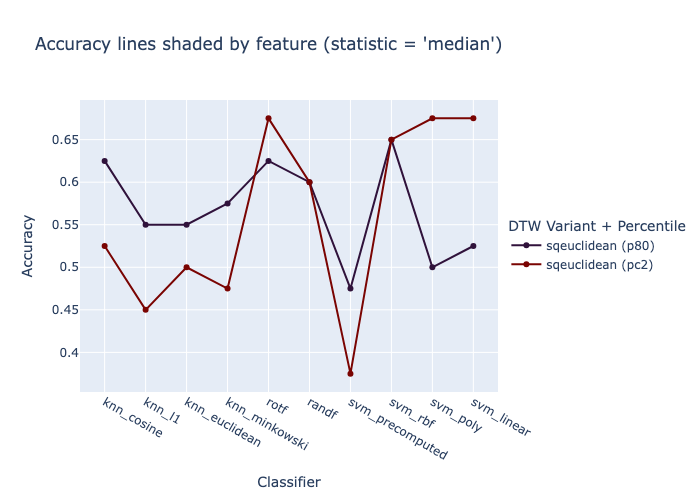

In [ ]:
#| eval: false

depict_accuracy_by_feature(         # visualize the classification accuracy across multiple classifiers and primary embeddings 
    dirname_soft,                   # directory from which the results are loaded
    features=['pc2', 'p80'],        # the features of the primary embeddings for which the accuracy will be visualized
    statistics='median',            # statistic to aggregate accuracy across multiple random states ('median', 'mean')
    columns_filter=COLUMNS_FILTER,  # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                    # for debugging
)

### Given a 1D-embedding, compare how accuracy changes across different distance metrics and classifiers
> These 1D-embeddings and distance metrics are parameters (primary embedding and `dist`) of the landmark embeddings.

 [DEBUG] cutils.depict_combined_accuracy: [INFO] Selected 6 rows with statistic = 'median'
 [DEBUG] cutils.depict_combined_accuracy: [INFO] Filtered to 3 DTW variants: ['euclidean', 'sqeuclidean', 'canberra']
 [DEBUG] cutils.depict_combined_accuracy: [INFO] Numeric columns detected: ['knn_l1', 'knn_cosine', 'knn_euclidean', 'knn_nan_euclidean', 'knn_minkowski', 'rotf', 'svm_rbf', 'svm_precomputed', 'svm_linear', 'svm_poly', 'svm_sigmoid', 'shapelet_rotationforest', 'randf', 'knn_precomputed']
 [DEBUG] cutils.depict_combined_accuracy: [INFO] Columns filtered to: ['knn_precomputed', 'knn_cosine', 'knn_l1', 'knn_euclidean', 'knn_minkowski', 'rotf', 'randf', 'svm_precomputed', 'svm_rbf', 'svm_poly', 'svm_linear']


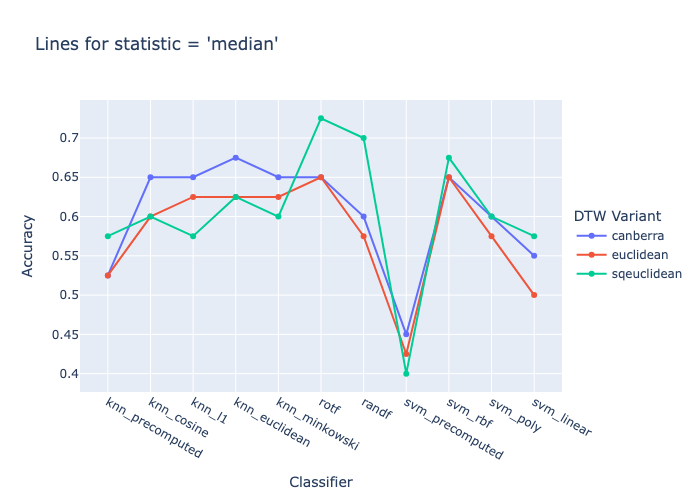

In [ ]:
#| eval: false

depict_combined_accuracy(                                  # given a primary embedding, visualize the classification accuracy across multiple classifiers and distance metrics  
    dirname_fast,                                          # directory from which the results are loaded 
    filename='acc_summ_pc2.xlsx',                          # filename that contains the results for the primary embedding (pc2 stands for the feature of the primary embedding)
    statistics='median',                                   # statistic to aggregate accuracy across multiple random states ('median', 'mean')
    dtw_filter=['euclidean', 'sqeuclidean', 'canberra'],   # list of distance metrics to include in the visualization
    columns_filter=COLUMNS_FILTER,                         # list of classifier columns to include in the visualization
    verbose=True                                           # for debugging
)